In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
#Cargar cojunto de datos segmentado
df = pd.read_csv("../data/clean/homeris-data-clean-cluster.csv")
from src.cleaning import cambio_nombre_grupo

cambio_nombre_grupo(df)

Grupos asignados y mapeados correctamente


,PERIODO,MUNICIPIO,DIAGNOSTICO,GENERO,REGIMEN,RANGO_EDAD,CANTIDAD_CASOS,ANIO,MES_NUM,PERIODO_MENSUAL,TRIMESTRE,MES_NOMBRE,SEMESTRE,GRUPO_DIAGNOSTICO,SALUD_MENTAL_CLASS,cluster
0,2024-01-01,ALCALA,OTROS TRASTORNOS DE ANSIEDAD,FEMENINO,CONTRIBUTIVO,60+,1,2024,1,2024-01,1,January,1,SALUD_MENTAL,SALUD_MENTAL,Grupo A
1,2024-01-01,ALCALA,PROBLEMAS RELACIONADOS CON EL GRUPO PRIMARIO D...,MASCULINO,SUBSIDIADO,29-59,1,2024,1,2024-01,1,January,1,FACTORES_SOCIALES,OTROS_GRUPOS_DX,Grupo B
2,2024-01-01,ALCALA,RETRASO MENTAL LEVE,MASCULINO,SUBSIDIADO,12-17,1,2024,1,2024-01,1,January,1,SALUD_MENTAL,SALUD_MENTAL,Grupo B
3,2024-01-01,ANSERMA,DORSALGIA,FEMENINO,SUBSIDIADO,29-59,1,2024,1,2024-01,1,January,1,MUSCULOESQUELETICO,OTROS_GRUPOS_DX,Grupo A
4,2024-01-01,ANSERMA,ESQUIZOFRENIA,MASCULINO,CONTRIBUTIVO,29-59,1,2024,1,2024-01,1,January,1,SALUD_MENTAL,SALUD_MENTAL,Grupo B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14678,2024-11-01,VITERBO,TRASTORNOS DELIRANTES PERSISTENTES,MASCULINO,SUBSIDIADO,29-59,1,2024,11,2024-11,4,November,2,SALUD_MENTAL,SALUD_MENTAL,Grupo B
14679,2024-11-01,VITERBO,TRASTORNOS DISOCIATIVOS [ DE CONVERSION ],MASCULINO,CONTRIBUTIVO,29-59,1,2024,11,2024-11,4,November,2,SALUD_MENTAL,SALUD_MENTAL,Grupo B
14680,2024-11-01,VITERBO,TRASTORNOS ESPECIFICOS DEL DESARROLLO DE LAS H...,MASCULINO,CONTRIBUTIVO,6-11,1,2024,11,2024-11,4,November,2,SALUD_MENTAL,SALUD_MENTAL,Grupo B
14681,2024-11-01,VITERBO,TRASTORNOS FOBICOS DE ANSIEDAD,FEMENINO,CONTRIBUTIVO,29-59,1,2024,11,2024-11,4,November,2,SALUD_MENTAL,SALUD_MENTAL,Grupo A


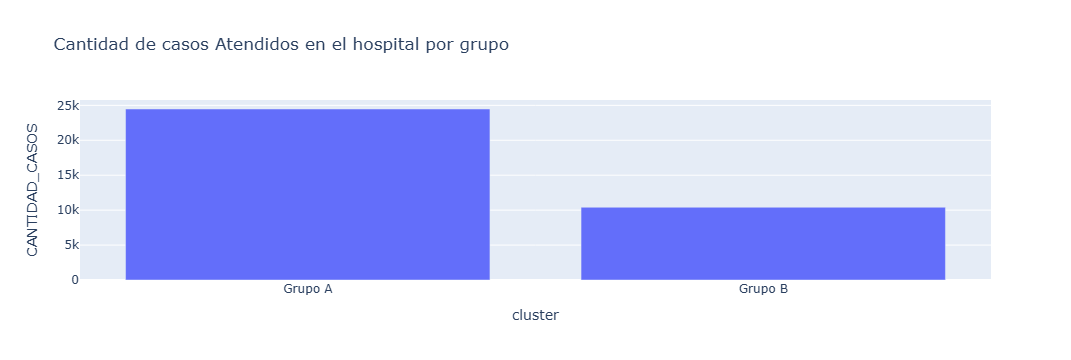

In [3]:
#Agrupación por cluster
df_group_cluster = df.groupby("cluster")["CANTIDAD_CASOS"].sum().reset_index()
#Calcular el %
df_group_cluster["PORCENTAJE_GRUPO"] = (
    df_group_cluster["CANTIDAD_CASOS"] / df_group_cluster["CANTIDAD_CASOS"].sum()
    ) * 100



df_group_cluster["PORCENTAJE_GRUPO"] = df_group_cluster["PORCENTAJE_GRUPO"].round(2)

fig_group_cluster = px.bar(
    df_group_cluster,
    y="CANTIDAD_CASOS",
    x = "cluster",
    hover_data = "PORCENTAJE_GRUPO",
    title ="Cantidad de casos Atendidos en el hospital por grupo")
fig_group_cluster.show()

In [4]:
df.columns

Index(['PERIODO', 'MUNICIPIO', 'DIAGNOSTICO', 'GENERO', 'REGIMEN',
       'RANGO_EDAD', 'CANTIDAD_CASOS', 'ANIO', 'MES_NUM', 'PERIODO_MENSUAL',
       'TRIMESTRE', 'MES_NOMBRE', 'SEMESTRE', 'GRUPO_DIAGNOSTICO',
       'SALUD_MENTAL_CLASS', 'cluster'],
      dtype='object')

In [5]:
df_genero = df.groupby(["cluster", "GENERO"])["CANTIDAD_CASOS"].sum().reset_index()

df_genero["PORCENTAJE"] = df_genero.groupby("cluster")["CANTIDAD_CASOS"]\
    .transform(lambda x: x / x.sum() * 100)

fig = px.bar(
    df_genero,
    x="cluster",
    y="CANTIDAD_CASOS",
    color="GENERO",
    barmode="relative",  # o "stack"
    title="Distribución por Género en cada Cluster"
)
fig.show()
#st.plotly_chart(fig, use_container_width=True)

In [6]:
df_genero

,cluster,GENERO,CANTIDAD_CASOS,PORCENTAJE
0,Grupo A,FEMENINO,17638,72.059484
1,Grupo A,MASCULINO,6839,27.940516
2,Grupo B,MASCULINO,10414,100.000000


In [7]:
df.groupby(["cluster", "GENERO"]).size()

cluster  GENERO   
Grupo A  FEMENINO     7134
         MASCULINO    2146
Grupo B  MASCULINO    5403
dtype: int64

In [8]:
df_group = df.groupby(["cluster", "GENERO"])["CANTIDAD_CASOS"].sum().reset_index()

df_group["PORCENTAJE"] = (
    df_group["CANTIDAD_CASOS"] /
    df_group.groupby("cluster")["CANTIDAD_CASOS"].transform("sum")
) * 100
df_group["PORCENTAJE"] = df_group["PORCENTAJE"].round(2)

In [9]:
df_group

,cluster,GENERO,CANTIDAD_CASOS,PORCENTAJE
0,Grupo A,FEMENINO,17638,72.06
1,Grupo A,MASCULINO,6839,27.94
2,Grupo B,MASCULINO,10414,100.00


In [10]:
df_A = df[df["cluster"] == "Grupo A"]
df_B = df[df["cluster"] == "Grupo B"]

In [11]:
df_edad_A = (
    df_A.groupby("RANGO_EDAD")["CANTIDAD_CASOS"]
        .sum()
        .reset_index()
        )

# Orden correcto (muy importante)
orden = ["0-5", "6-11", "12-17", "18-28", "29-59", "60+"]

df_edad_A["RANGO_EDAD"] = pd.Categorical(df_edad_A["RANGO_EDAD"], categories=orden, ordered=True)
df_edad_A = df_edad_A.sort_values("RANGO_EDAD")

fig_edad_A = px.bar(
    df_edad_A,
    x="CANTIDAD_CASOS",
    y="RANGO_EDAD",
    orientation="h",
    text="CANTIDAD_CASOS",
    title="Distribución de casos por rango de edad"
)
fig_edad_A.show()




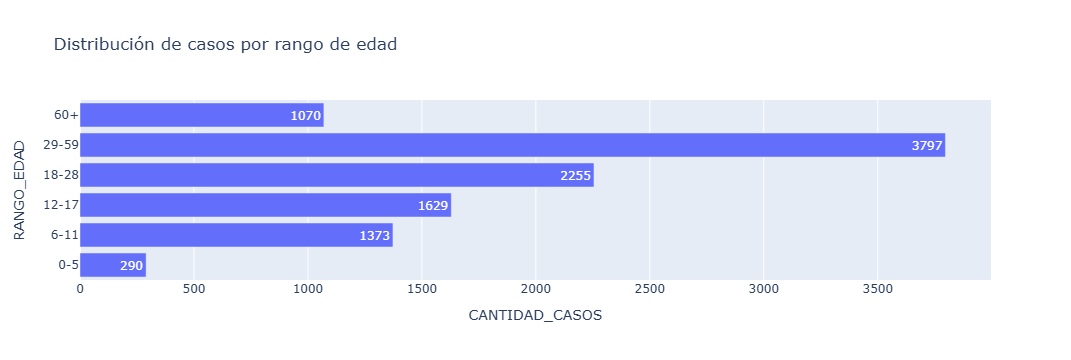

In [12]:
df_edad_B = (
    df_B.groupby("RANGO_EDAD")["CANTIDAD_CASOS"]
        .sum()
        .reset_index()
        )

# Orden correcto (muy importante)
orden = ["0-5", "6-11", "12-17", "18-28", "29-59", "60+"]

df_edad_B["RANGO_EDAD"] = pd.Categorical(df_edad_B["RANGO_EDAD"], categories=orden, ordered=True)
df_edad_B = df_edad_B.sort_values("RANGO_EDAD")

fig_edad_B = px.bar(
    df_edad_B,
    x="CANTIDAD_CASOS",
    y="RANGO_EDAD",
    orientation="h",
    text="CANTIDAD_CASOS",
    title="Distribución de casos por rango de edad"
)
fig_edad_B.show()

In [13]:
df_edad = df.groupby(["cluster", "RANGO_EDAD"])["CANTIDAD_CASOS"].sum().reset_index()

df_edad["PORCENTAJE"] = df_edad.groupby("cluster")["CANTIDAD_CASOS"]\
    .transform(lambda x: x / x.sum() * 100)

# Orden correcto (muy importante)
orden = ["0-5", "6-11", "12-17", "18-28", "29-59", "60+"]

df_edad["RANGO_EDAD"] = pd.Categorical(df_edad["RANGO_EDAD"], categories=orden, ordered=True)
df_edad = df_edad.sort_values("RANGO_EDAD")

df_diff = df_edad.pivot(index="RANGO_EDAD", columns="cluster", values="PORCENTAJE").reset_index()
df_diff["DIFERENCIA"] = df_diff["Grupo B"] - df_diff["Grupo A"]



fig = px.bar(
    df_edad,
    x="PORCENTAJE",
    y="RANGO_EDAD",
    color="cluster",
    orientation="h",
    barmode="group",
    title="Distribución porcentual por rango de edad y cluster"
)
fig.show()


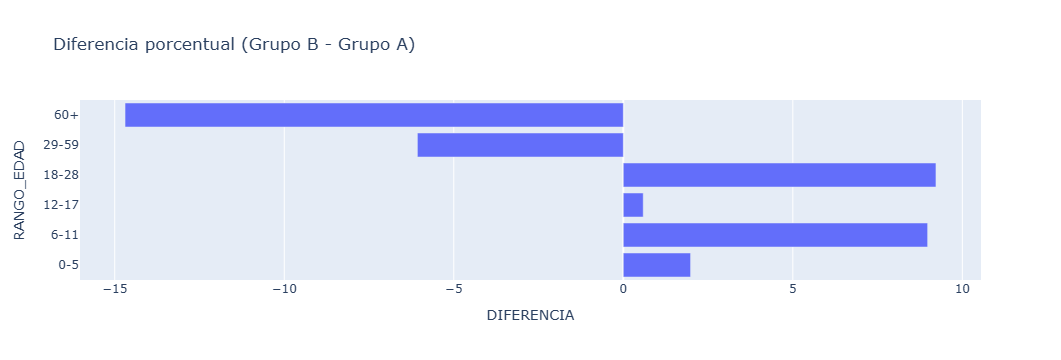

In [14]:
fig_diff = px.bar(
    df_diff,
    x="DIFERENCIA",
    y="RANGO_EDAD",
    orientation="h",
    title="Diferencia porcentual (Grupo B - Grupo A)"
)

fig_diff.show()

In [15]:
df_diff

cluster,RANGO_EDAD,Grupo A,Grupo B,DIFERENCIA
0,0-5,0.800752,2.784713,1.983961
1,6-11,4.208032,13.184175,8.976143
2,12-17,15.054950,15.642404,0.587455
3,18-28,12.432079,21.653543,9.221464
4,29-59,42.533807,36.460534,-6.073273
5,60+,24.970380,10.274630,-14.695750


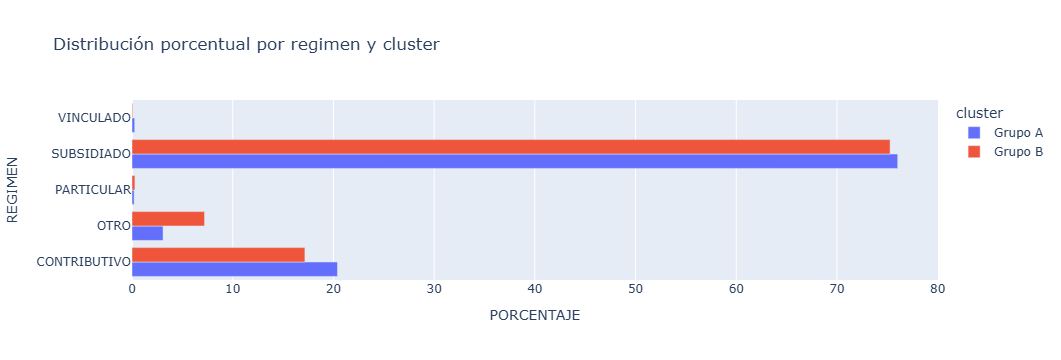

In [24]:
df_regimen = df.groupby(["cluster", "REGIMEN"])["CANTIDAD_CASOS"].sum().reset_index()

df_regimen["PORCENTAJE"] = df_regimen.groupby("cluster")["CANTIDAD_CASOS"]\
    .transform(lambda x: x / x.sum() * 100)


df_diff_regimen = df_regimen.pivot(index="REGIMEN", columns="cluster", values="PORCENTAJE").reset_index()
df_diff_regimen["DIFERENCIA"] = df_diff_regimen["Grupo B"] - df_diff_regimen["Grupo A"]



fig = px.bar(
    df_regimen,
    x="PORCENTAJE",
    y="REGIMEN",
    color="cluster",
    orientation="h",
    barmode="group",
    title="Distribución porcentual por regimen y cluster"
)
fig.show()

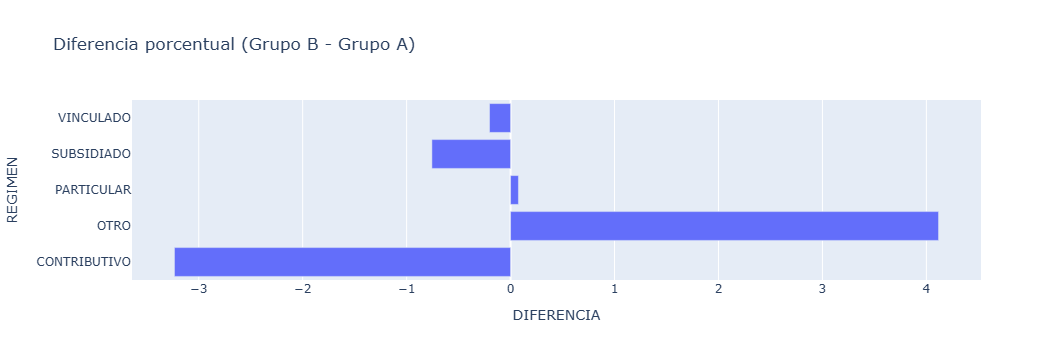

In [25]:
fig_diff_regimen = px.bar(
    df_diff_regimen,
    x="DIFERENCIA",
    y="REGIMEN",
    orientation="h",
    title="Diferencia porcentual (Grupo B - Grupo A)"
)


fig_diff_regimen.show()

In [26]:
df_diff_regimen

cluster,REGIMEN,Grupo A,Grupo B,DIFERENCIA
0,CONTRIBUTIVO,20.402827,17.169195,-3.233632
1,OTRO,3.084528,7.201844,4.117315
2,PARTICULAR,0.212444,0.288074,0.075629
3,SUBSIDIADO,76.030559,75.273670,-0.756889
4,VINCULADO,0.269641,0.067217,-0.202424


In [23]:
df.columns

Index(['PERIODO', 'MUNICIPIO', 'DIAGNOSTICO', 'GENERO', 'REGIMEN',
       'RANGO_EDAD', 'CANTIDAD_CASOS', 'ANIO', 'MES_NUM', 'PERIODO_MENSUAL',
       'TRIMESTRE', 'MES_NOMBRE', 'SEMESTRE', 'GRUPO_DIAGNOSTICO',
       'SALUD_MENTAL_CLASS', 'cluster'],
      dtype='object')

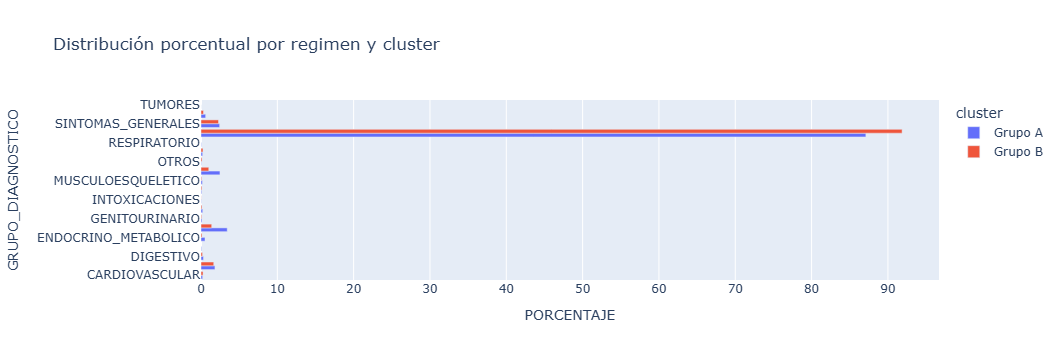

In [28]:
df_grupo_dx = df.groupby(["cluster", "GRUPO_DIAGNOSTICO"])["CANTIDAD_CASOS"].sum().reset_index()

df_grupo_dx["PORCENTAJE"] = df_grupo_dx.groupby("cluster")["CANTIDAD_CASOS"]\
    .transform(lambda x: x / x.sum() * 100)


df_diff_grupo_dx = df_grupo_dx.pivot(index="GRUPO_DIAGNOSTICO", columns="cluster", values="PORCENTAJE").reset_index()
df_diff_grupo_dx["DIFERENCIA"] = df_diff_grupo_dx["Grupo B"] - df_diff_grupo_dx["Grupo A"]



fig_grupo_dx = px.bar(
    df_grupo_dx,
    x="PORCENTAJE",
    y="GRUPO_DIAGNOSTICO",
    color="cluster",
    orientation="h",
    barmode="group",
    title="Distribución porcentual por regimen y cluster"
)
fig.show()

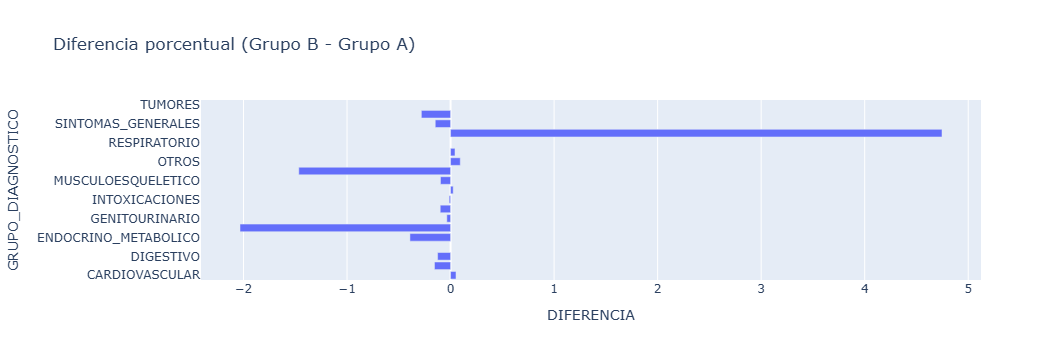

In [30]:
fig_diff_grupo_dx = px.bar(
    df_diff_grupo_dx,
    x="DIFERENCIA",
    y="GRUPO_DIAGNOSTICO",
    orientation="h",
    title="Diferencia porcentual (Grupo B - Grupo A)"
)


fig_diff_grupo_dx.show()

In [31]:
df_diff_grupo_dx

cluster,GRUPO_DIAGNOSTICO,Grupo A,Grupo B,DIFERENCIA
0,CARDIOVASCULAR,0.216530,0.268869,0.052339
1,CONTACTO_SERVICIOS_SALUD,1.826204,1.670828,-0.155376
2,DIGESTIVO,0.326837,0.201652,-0.125186
3,EMBARAZO,0.065367,NaN,NaN
4,ENDOCRINO_METABOLICO,0.527025,0.134434,-0.392591
5,FACTORES_SOCIALES,3.435879,1.401959,-2.033920
6,GENITOURINARIO,0.122564,0.086422,-0.036142
7,INFECTOLOGIA,0.224701,0.124832,-0.099869
8,INTOXICACIONES,0.032684,0.019205,-0.013479
9,MALFORMACIONES_CONGENITAS,0.089880,0.115229,0.025349
